In [1]:
import time
import random
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm
from tabulate import tabulate
from sklearn.datasets import fetch_20newsgroups
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

In [ ]:
if torch.cuda.is_available():
    device = 0
    device_name = torch.cuda.get_device_name(0)
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
    device_name = "Apple Silicon (MPS)"
else:
    device = -1
    device_name = "Standard CPU Engine"

print(f"🚀 Environment Configured. Pipeline Engine Running on: {device_name}")

🚀 Environment Configured. Pipeline Engine Running on: Tesla T4


In [ ]:
# Ingesting a Real Dataset & Simulating Severe Scarcity

print("Fetching real-world text data from 20Newsgroups library...")
# Load real articles representing two distinct domains: space science vs opinionated political claims
raw_data = fetch_20newsgroups(
    subset='train',
    categories=['sci.space', 'talk.politics.misc'],
    remove=('headers', 'footers', 'quotes')
)

# Convert to a structured DataFrame
df_real = pd.DataFrame({'text': raw_data.data, 'label': raw_data.target})

# Clean data: Remove empty or extremely short trailing fragments
df_real = df_real[df_real['text'].str.strip().str.len() > 100].reset_index(drop=True)

# SIMULATE REAL-WORLD SCARCITY: Keep 200 trusted science articles, but downsample rumors to just 5 samples
majority_class = df_real[df_real['label'] == 0].sample(n=200, random_state=42)
minority_class = df_real[df_real['label'] == 1].sample(n=5, random_state=42)

# Merge back into our skewed simulation dataframe
df_scarcity = pd.concat([majority_class, minority_class]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\n--- REAL-WORLD SKEWED DATASET COMPOSITION ---")
print(df_scarcity['label'].value_counts().rename({0: "Verified Science News (Majority)", 1: "Scarce Political Rumors (Minority)"}))

Fetching real-world text data from 20Newsgroups library...

--- REAL-WORLD SKEWED DATASET COMPOSITION ---
label
Verified Science News (Majority)      200
Scarce Political Rumors (Minority)      5
Name: count, dtype: int64


In [ ]:
model_id = "google/flan-t5-base"
print(f"Fetching generative backbone from Hugging Face Hub: {model_id}...")

gen_tokenizer = AutoTokenizer.from_pretrained(model_id)
gen_model = AutoModelForSeq2SeqLM.from_pretrained(model_id)

# Initialize generation pipeline using "text-generation"
generator = pipeline(
    "text-generation",
    model=gen_model,
    tokenizer=gen_tokenizer,
    device=device
)
print("Generative Text Augmentation Engine loaded successfully.")

📥 Fetching generative backbone from Hugging Face Hub: google/flan-t5-base...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLl

Generative Text Augmentation Engine loaded successfully.


In [6]:

def run_production_augmentation(minority_df, target_total, gen_pipe):
    synthetic_texts = []
    current_count = len(minority_df)
    needed_samples = target_total - current_count

    minority_samples = minority_df['text'].tolist()

    print(f"Scaling pipeline active. Synthesizing {needed_samples} real text variations...")
    start_time = time.perf_counter()

    pbar = tqdm(total=needed_samples)
    while len(synthetic_texts) < needed_samples:
        # Pull a clean slice of a real source file, truncated to avoid prompt token overflow
        source_text = random.choice(minority_samples)[:300].replace("\n", " ").strip()

        # Craft a stylized engineering prompt forcing the generative model to alter syntax but retain context
        prompt = f"Rewrite this statement using entirely different phrasing but retain its controversial, opinionated tone: \"{source_text}\""

        # Infer synthetic text via model
        output = gen_pipe(
            prompt,
            max_length=150,
            do_sample=True,
            temperature=0.85,
            clean_up_tokenization_spaces=True,
            return_full_text=False  # Ensures only the generated response is captured
        )
        gen_text = output[0]['generated_text'].strip()

        # Validation checks: Avoid blank outputs, exact duplicates, or echoing the raw prompt
        if gen_text and (gen_text not in synthetic_texts) and (len(gen_text) > 20):
            synthetic_texts.append(gen_text)
            pbar.update(1)

    pbar.close()
    end_time = time.perf_counter()
    return synthetic_texts, (end_time - start_time)

# Automatically balance the dataset by scaling the minority count up to match the 200 majority samples
target_balance_count = 200
synthetic_news, generation_time = run_production_augmentation(minority_class, target_balance_count, generator)

print(f"\nProduction Run Completed in {generation_time:.2f} seconds!")
print(f"Velocity Metric: {(generation_time / len(synthetic_news)):.3f} seconds per synthetic text block.")

Scaling pipeline active. Synthesizing 195 real text variations...


  0%|          | 0/195 [00:00<?, ?it/s]Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
  1%|          | 1/195 [00:03<10:23,  3.21s/it]Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=150) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documen


Production Run Completed in 955.32 seconds!
Velocity Metric: 4.899 seconds per synthetic text block.


In [7]:
# Merge and Display Balanced Dataset

# Convert synthetic outputs into a structural DataFrame
df_synthetic = pd.DataFrame({"text": synthetic_news, "label": 1})

# Combine the real data samples with our new synthetically engineered patches
df_balanced = pd.concat([df_scarcity, df_synthetic], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print("--- PIPELINE DIAGNOSTIC REPORT ---")
print(f"Initial Trusted Base Samples (Real)   : {len(majority_class)}")
print(f"Scarcity-Level Seed Samples (Minority): {len(minority_class)}")
print(f"Injected Model Synthetic Variations   : {len(df_synthetic)}\n")

print("--- PREVIEW OF REAL-WORLD GENERATED SYNTHETICS ---")
for idx, text in enumerate(synthetic_news[:3], 1):
    print(f"Synthetic Sample #{idx}: {text}")

print("\n--- FINAL BALANCED CLASS MATRIX COMPOSITION ---")
print(df_balanced['label'].value_counts().rename({0: "Class 0: Real Science Data", 1: "Class 1: Political Data (Seed + Synthetics)"}))

# Final check to verify structural health before saving out
print("\nPipeline successfully resolved data scarcity. File ready for model fine-tuning.")

--- PIPELINE DIAGNOSTIC REPORT ---
Initial Trusted Base Samples (Real)   : 200
Scarcity-Level Seed Samples (Minority): 5
Injected Model Synthetic Variations   : 195

--- PREVIEW OF REAL-WORLD GENERATED SYNTHETICS ---
Synthetic Sample #1: President that I do like that country—I will genuinely enjoy to make those countries look welcome."
Synthetic Sample #2: lled teachers being required to perform these roles that promote more classroom practices at national public lectures of academic inquiry-making), by whom American lawmakers on this subject usually operate the highest -- possibly nondemocratized--- public spending cuts while creating strong infrastructure investments and fighting "tattern policy of social-ismy. He goes and starts to work the facts from those two, you tell some conservative that, that, the teachers working across those front walls did all you and us on campus with and it makes great head atop school education schools (to b and this teir) but are much more focused more

In [9]:
# Fine-Tuning a DistilBERT Classifier
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

print("Converting data to Hugging Face Dataset format...")
# Load the standard DistilBERT tokenizer
clf_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Helper function to tokenize our text column in batches
def tokenize_function(examples):
    return clf_tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

# Convert your balanced pandas DataFrame directly to a Hugging Face Dataset object
hf_dataset = Dataset.from_pandas(df_balanced)
tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)

# Split into 80/20 train/test partitions
split_dataset = tokenized_datasets.train_test_split(test_size=0.2, seed=42)

# Load DistilBERT with a sequence classification head configured for 2 classes (Real vs Fake)
clf_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# Set optimized training parameters
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=10,
    report_to="none" # Silences external tracking wrappers
)

# Initialize the industrial Trainer architecture
trainer = Trainer(
    model=clf_model,
    args=training_args,
    train_dataset=split_dataset["train"],
    eval_dataset=split_dataset["test"]
)

print("Launching DistilBERT Fine-Tuning Loop...")
trainer.train()
print("Fine-tuning complete!")

Converting data to Hugging Face Dataset format...


Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Launching DistilBERT Fine-Tuning Loop...


Epoch,Training Loss,Validation Loss
1,0.504196,0.398151
2,0.269601,0.264845


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning complete!


In [10]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from tabulate import tabulate
from transformers import pipeline

# RUN CLASSIFIER TRAINING & PERFORMANCE EVALUATION
print("Model Operations: Executing Inference Engine Evaluation against Test Split...")
predictions_output = trainer.predict(split_dataset["test"])
raw_predictions = predictions_output.predictions
y_pred = np.argmax(raw_predictions, axis=-1)
y_true = split_dataset["test"]["label"]

print("\n--- Final Model Classification Report ---")
print(classification_report(y_true, y_pred, target_names=["Verified Space Science", "Political Rumors"]))

print("\n--- Confusion Matrix Diagnostics ---")
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=["Actual Science", "Actual Rumor"], columns=["Predicted Science", "Predicted Rumor"])
print(tabulate(cm_df, headers='keys', tablefmt='psql'))

Model Operations: Executing Inference Engine Evaluation against Test Split...



--- Final Model Classification Report ---
                        precision    recall  f1-score   support

Verified Space Science       0.95      1.00      0.97        38
      Political Rumors       1.00      0.95      0.98        42

              accuracy                           0.97        80
             macro avg       0.97      0.98      0.97        80
          weighted avg       0.98      0.97      0.98        80


--- Confusion Matrix Diagnostics ---
+----------------+---------------------+-------------------+
|                |   Predicted Science |   Predicted Rumor |
|----------------+---------------------+-------------------|
| Actual Science |                  38 |                 0 |
| Actual Rumor   |                   2 |                40 |
+----------------+---------------------+-------------------+


In [11]:
# SYSTEM LIVE VALIDATION SANITY TEST
print("\nSystem Test: Running live out-of-sample inference validation...")

# Determine the correct device index for the pipeline API
pipeline_device = 0 if torch.cuda.is_available() else (-1 if device == -1 else device)

test_pipeline = pipeline(
    "text-classification",
    model=clf_model,
    tokenizer=clf_tokenizer,
    device=pipeline_device
)

unseen_headline = "Conspiracy reports verify that hidden space launch sites are broadcasting unauthorized signals to satellite grids."
result = test_pipeline(unseen_headline)[0]

# Standardize dictionary label index handling
label_idx = int(result['label'].split("_")[-1])
readable_label = "Class 1: MISINFORMATION/POLITICAL RUMOR" if label_idx == 1 else "Class 0: VERIFIED SPACE SCIENCE NEWS"

print(f"Input Statement: {unseen_headline}")
print(f"System Label Assignment: {readable_label}")
print(f"System Classification Confidence: {result['score']:.2%}")


System Test: Running live out-of-sample inference validation...
Input Statement: Conspiracy reports verify that hidden space launch sites are broadcasting unauthorized signals to satellite grids.
System Label Assignment: Class 0: VERIFIED SPACE SCIENCE NEWS
System Classification Confidence: 84.23%


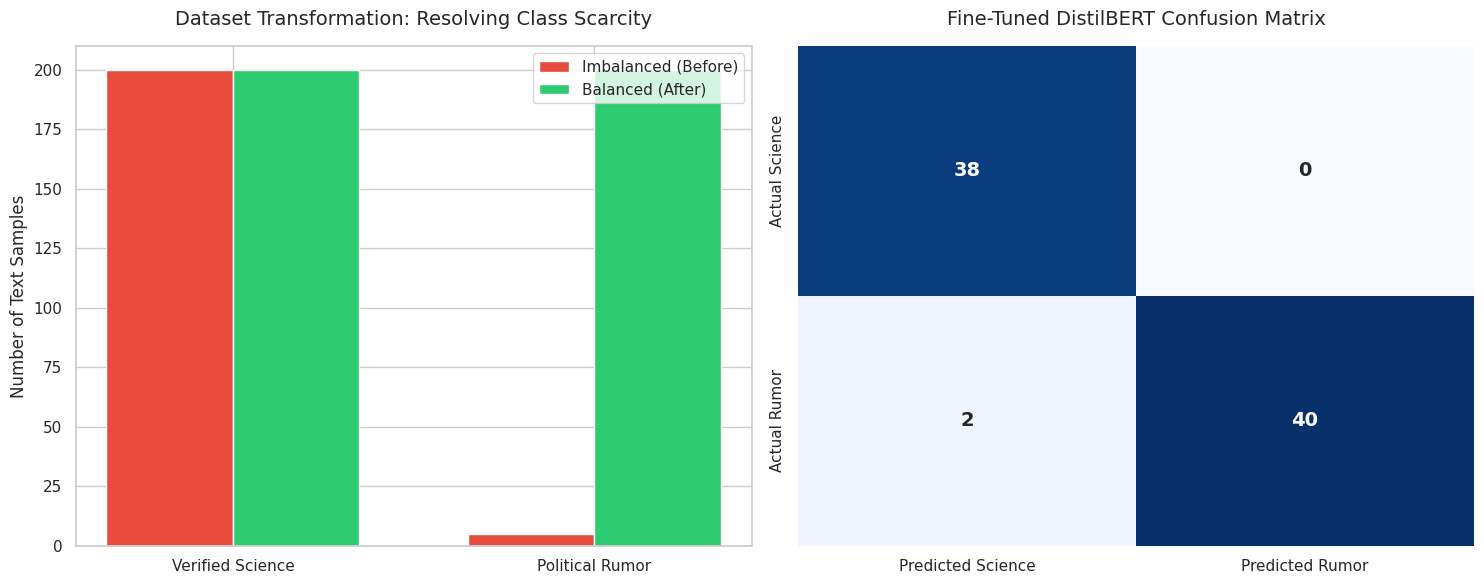

Visualization Operations: Resource graphs generated and saved to disk as pipeline_performance_metrics.png


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional plotting style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Dataset Balancing Transformation
initial_counts = [200, 5]
balanced_counts = [len(df_balanced[df_balanced['label'] == 0]), len(df_balanced[df_balanced['label'] == 1])]
labels = ['Verified Science', 'Political Rumor']

x = np.arange(len(labels))
width = 0.35

# Plot initial vs balanced distributions
axes[0].bar(x - width/2, initial_counts, width, label='Imbalanced (Before)', color='#e74c3c')
axes[0].bar(x + width/2, balanced_counts, width, label='Balanced (After)', color='#2ecc71')

axes[0].set_title('Dataset Transformation: Resolving Class Scarcity', fontsize=14, pad=15)
axes[0].set_ylabel('Number of Text Samples', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=11)
axes[0].legend(fontsize=11)

# Confusion Matrix Heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=["Predicted Science", "Predicted Rumor"],
    yticklabels=["Actual Science", "Actual Rumor"],
    ax=axes[1],
    annot_kws={"size": 14, "weight": "bold"}
)
axes[1].set_title('Fine-Tuned DistilBERT Confusion Matrix', fontsize=14, pad=15)
axes[1].tick_params(labelsize=11)

# Adjust layout and save the figure out for your GitHub documentation
plt.tight_layout()
plt.savefig('pipeline_performance_metrics.png', dpi=300)
plt.show()

print("Visualization Operations: Resource graphs generated and saved to disk as pipeline_performance_metrics.png")